# Monte-Carlo methods

<style>
.MathJax {
  font-family: "Common HTML";
}
</style>

$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\operatornamewithlimits{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
\newcommand{\loss}{\ell}
\newcommand{\eloss}{\mc{L}}
\newcommand{\abs}[1]{| #1 |}
\newcommand{\norm}[1]{\| #1 \|}
\newcommand{\tp}{T}
$$

__<div style="text-align: right"> ASE3001: Computational Experiments for Aerospace Engineering, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_

<br>

___

<br>

Monte Carlo methods are a broad class of computational algorithms that rely on repeated random sampling to obtain numerical results. Their essential idea is using randomness to solve problems that might be deterministic in principle. They are often used in physical and mathematical problems and are most useful when it is difficult or impossible to use other approaches. Monte Carlo methods are mainly used in three distinct problem classes: optimization, numerical integration, and generating draws from a probability distribution.

<br>

___

<br>

## Monte-Carlo integration

In this problem we will work on Monte-Carlo simulations with Python. The first thing we will do is a basic crude Monte-Carlo method for evaluating definite integrals. Consider the following integral

$$
I = \int_0^{\infty} \frac{e^{-x}}{1+\left(x-1\right)^2}dx
$$

where we denote the integrand by $f(x) = \frac{e^{-x}}{1+\left(x-1\right)^2}$. The following shows what the integrand looks like, and the area below the function is something we want to estimate.


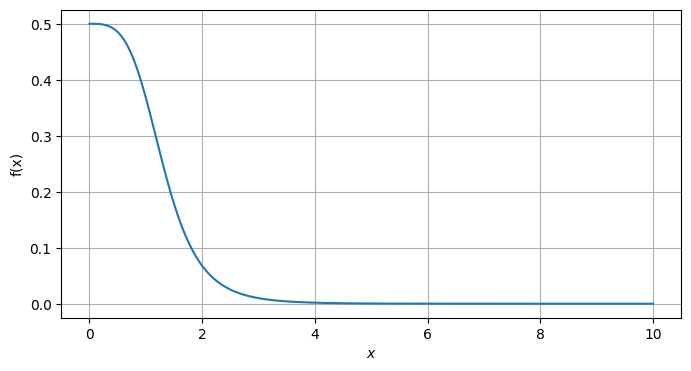

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,10,1000)

f = np.exp(-x)/(1+(x-1)**2)

plt.figure(figsize=(8,4), dpi=100)
plt.plot(x,f)
plt.grid()
plt.xlabel(r'$x$')
plt.ylabel(r'f(x)')
plt.show()

Recall the mean value theorem stated below.

$$
  f_\text{mean} = \frac{1}{b-a}\int_a^b f(x)dx
$$

So the basic idea is to randomly sample $x$ and evaluate $f(x)$ from the range, $0<x<y$, to estimate $\hat{f}_\text{mean}$. Then the integral estimation is simply $\left(b-a\right)\hat{f}_\text{mean}$. Since $f(x)$ exponentially decreases as $x$ increases, the integration range around $0<x<6$ would be a reasonable choice.

The following code shows the estimates of $for a variety of sample sizes.


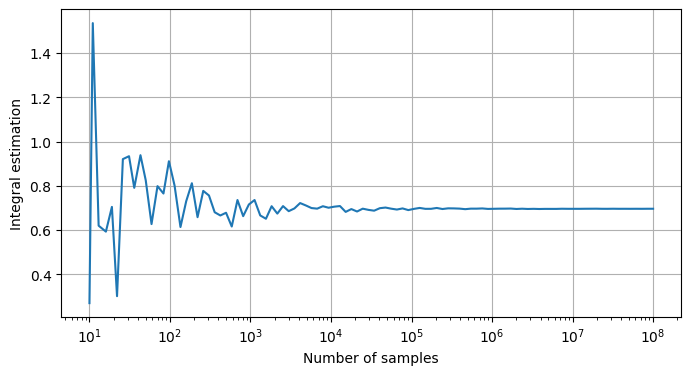

In [ ]:
y = 6
K = 100
m = np.logspace(1,8,K, dtype='int')
estim = np.zeros(K)

for k in range(K):
  xs = np.random.rand(m[k])*y
  estim[k] = np.mean(np.exp(-xs)/(1+(xs-1)**2))*y

plt.figure(figsize=(8,4), dpi=100)
plt.semilogx(m,estim)
plt.grid()
plt.xlabel('Number of samples')
plt.ylabel('Integral estimation')
plt.show()

You can compare your solution with a more accurate estimate presented at  [https://www.wolframalpha.com/input/?i=integral+of+0+to+inf+of+e%5E(-x)%2F(1%2B(x-1)%5E2)](https://www.wolframalpha.com/input/?i=integral+of+0+to+inf+of+e%5E(-x)%2F(1%2B(x-1)%5E2))



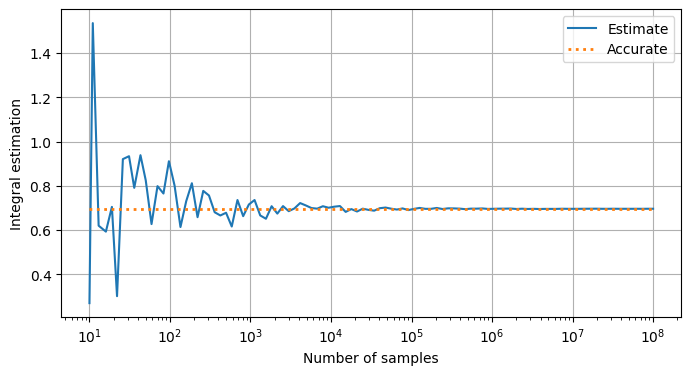

In [ ]:
plt.figure(figsize=(8,4), dpi=100)
plt.semilogx(m,estim, label='Estimate')
plt.semilogx(m,0.6960918269*np.ones(K), ':', linewidth=2, label='Accurate')
plt.grid()
plt.legend()
plt.xlabel('Number of samples')
plt.ylabel('Integral estimation')
plt.show()

<br>

___

<br>

## Numerical approximation of $\pi$

The same technique can be used to find the numerical approximation of  $\pi$.

Consider a square grid on $-1\le x_1\le 1$ and $-1\le x_2\le 1$, with the unit circle centered at the origin.


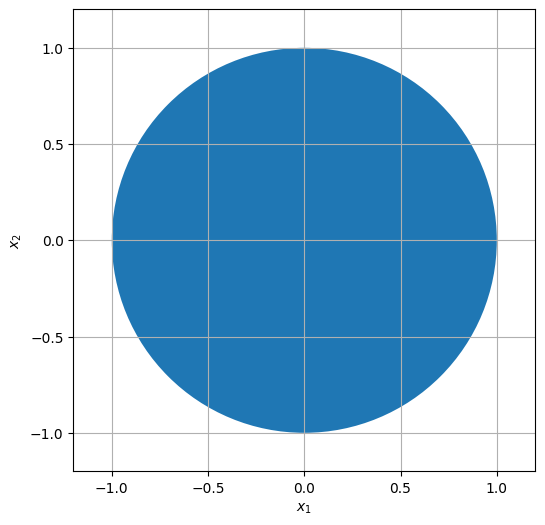

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6), dpi=100)
plt.gcf().gca().add_artist(plt.Circle((0, 0), 1))
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.axis('square')
plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)
plt.grid()
plt.show()

Additionally we define the following indicator function

$$
  f(x_1, x_2) =
  \begin{cases}
  1 &\quad \text{if } x_1^2 + x_2^2 \le 1\\
  0 &\quad \text{otherwise}
  \end{cases}
$$

so the definite integral on the square gives the area of the unit circle

\begin{aligned}
I &= \int_{-1}^1 \int_{-1}^1f(x_1,x_2)dx_1 dx_2 \\
  &= \pi
\end{aligned}


and the mean value theorem for double integrals states

\begin{align*}
  f_\text{mean} &= \frac{1}{b_1-a_1}\frac{1}{b_2-a_2}\int_{a_2}^{b_2}\int_{a_1}^{b_1} f(x_1,x_2) dx_1 dx_2\\
  &= \frac{\pi}{4}
\end{align*}

therefore we have that

$$
  \pi = 4f_\text{mean}
$$

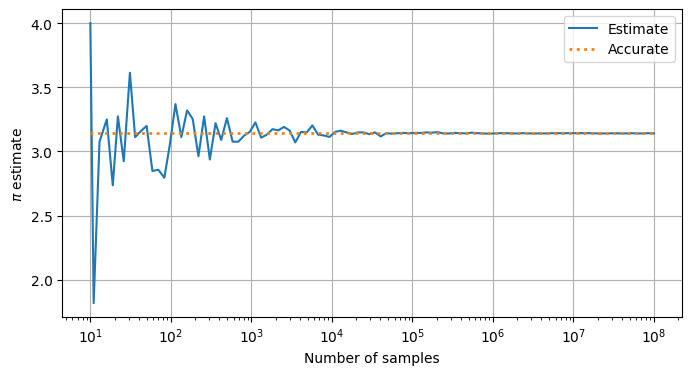

In [ ]:
def unit_circle_indicator(x):
  return np.floor(np.linalg.norm(x,axis=0)<1)

K = 100
m = np.logspace(1,8,K, dtype='int')
estim = np.zeros(K)

for k in range(K):
  xs = np.random.rand(2,m[k])*2 - 1
  estim[k] = np.mean(unit_circle_indicator(xs))*4

plt.figure(figsize=(8,4), dpi=100)
plt.semilogx(m,estim, label='Estimate')
plt.semilogx(m,np.pi*np.ones(K), ':', linewidth=2, label='Accurate')
plt.grid()
plt.legend()
plt.xlabel('Number of samples')
plt.ylabel(r'$\pi$ estimate')
plt.show()

<br>

___

<br>

## Volume of an $n$-ball

In geometry, a unit ball is a region in space comprising all points within a unit distance from a given point; that is, it is the region enclosed by a sphere or hypersphere. A unit$n$-ball is a unit ball in $n$-dimensional Euclidean space. The volume of a unit $n$-ball is an important constant that occurs in formulas throughout mathematics; it generalizes the notion of the volume enclosed by a unit sphere in 3-dimensional space.

We follow the Monte-Carlo integration approches which  are especially efficient for higher dimensional problems, where numerical integration on regular grids is inefficient. An indicator function for the $n$ dimensional unit ball with $x=(x_1,\dots,x_n)$ can be defined by

$$
  f(x) =
  \begin{cases}
  1 &\quad \text{if } \|x\|_2 \le 1\\
  0 &\quad \text{otherwise}
  \end{cases}
$$

and the $n$-volume of the $n$ dimensional unit ball is equal to the definite integral of $f(x)$ on the hypercube

\begin{aligned}
V_n &= \int_{-1}^1 \dots \int_{-1}^1f(x)dx_1 \dots dx_n
\end{aligned}

and the mean value theorem states

\begin{align*}
  f_\text{mean} &= \frac{1}{2^n}\int_{-1}^1 \dots \int_{-1}^1f(x)dx_1 \dots dx_n
\end{align*}

Therefore, once we computed the estimate of the mean value, $\hat{f}_\text{mean}$, then the volume of the unit $n$-ball is simply given by

 $$
 V_n = 2^n \hat{f}_\text{mean}
 $$

 For example, the following code computes the volume of the 6-dimensional unit ball.

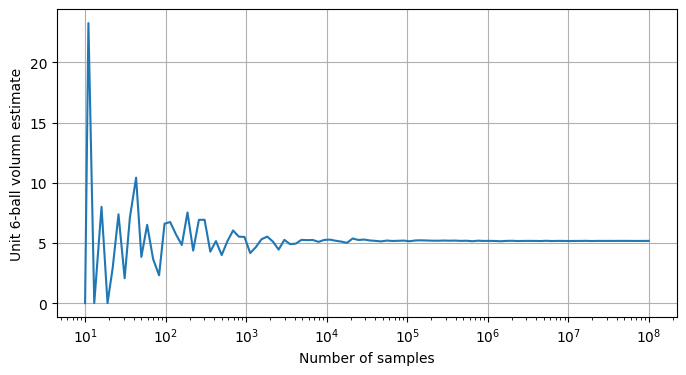

In [ ]:
def unit_ball_indicator(x):
  return np.floor(np.linalg.norm(x,axis=0)<1)

K = 100
m = np.logspace(1,8,K, dtype='int')
estim = np.zeros(K)

for k in range(K):
  xs = np.random.rand(6,m[k])*2 - 1
  estim[k] = np.mean(unit_ball_indicator(xs))*2**6

plt.figure(figsize=(8,4), dpi=100)
plt.semilogx(m,estim)
plt.grid()
plt.xlabel('Number of samples')
plt.ylabel(r'Unit 6-ball volumn estimate')
plt.show()

The code below estimates the volume of unit $n$-balls with $n=0,\dots,16$ with one million samples for each $n$.

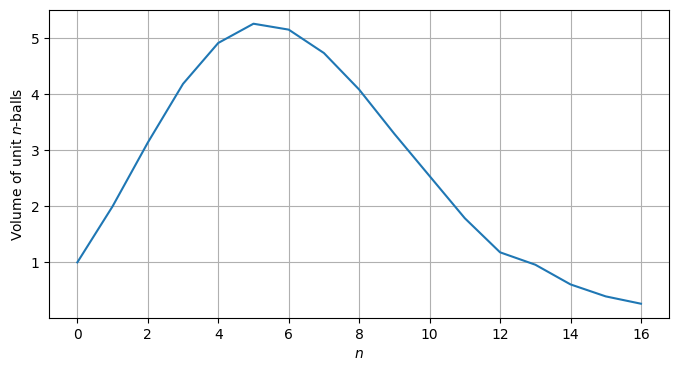

In [ ]:
m = 1000000
N = 17
n_list = np.arange(N, dtype='int')
estim = np.zeros(N)

for i in range(N):
  n = n_list[i]
  xs = np.random.rand(n,m)*2 - 1
  estim[i] = np.mean(unit_ball_indicator(xs))*(2**n)

plt.figure(figsize=(8,4), dpi=100)
plt.plot(n_list,estim)
plt.grid()
plt.xlabel(r'$n$')
plt.ylabel(r'Volume of unit $n$-balls')
plt.show()

You can compare your solution with the exact solution presented at https://en.wikipedia.org/wiki/Volume_of_an_n-ball.



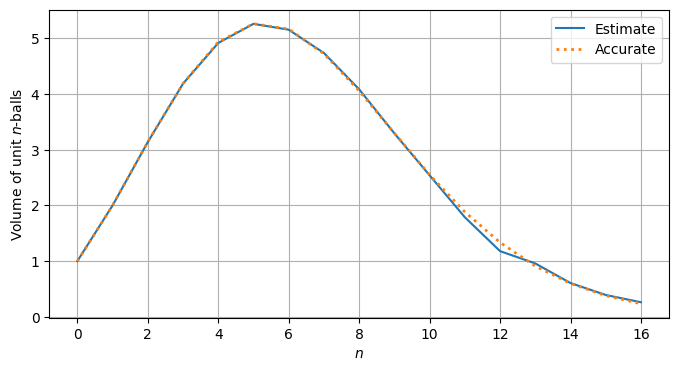

In [ ]:
from scipy.special import gamma
true_volume = np.pi**(n_list/2)/gamma(n_list/2+1)

plt.figure(figsize=(8,4), dpi=100)
plt.plot(n_list, estim, label='Estimate')
plt.plot(n_list, true_volume, ':', linewidth=2, label='Accurate')
plt.grid()
plt.legend()
plt.xlabel(r'$n$')
plt.ylabel(r'Volume of unit $n$-balls')
plt.show()

<br>

___

<br>

## Random walk

A Monte Carlo simulation technique will be used for investigating the potential evolution of asset prices over time. We assume that the evolution is subject to daily returns that follow a normal distribution. This type of price evolution is also known as a “random walk”.

<br>

The following pieces of codes load the market prices for Alphabet Inc. (GOOGL) over the past 20 years.


In [ ]:
!pip install yfinance

[*********************100%***********************]  1 of 1 completed


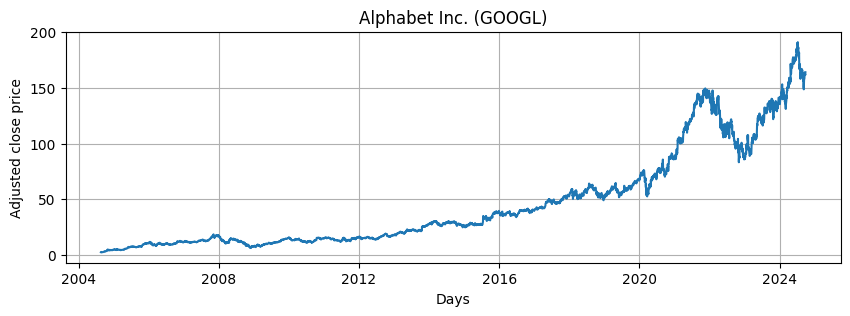

In [ ]:
import yfinance as yf
alpha = yf.download('GOOGL', start='2004-08-19')
price = alpha['Adj Close'].values

plt.figure(figsize=(10,3), dpi=100)
plt.plot(alpha.index, price)
plt.grid(True)
plt.xlabel('Days')
plt.ylabel('Adjusted close price')
plt.title('Alphabet Inc. (GOOGL)')
plt.show()

<br>

The daily return is the daily growth rate in percentage,

$$
  r_t = \frac{p_t - p_{t-1}}{p_{t-1}}\times 100 \text{  (%)}
$$


where $p_t$ represents the price at day $t$.

<br>

The volatility is defined by the standard deviation of the return, and the annual volatility $v$ is the standard deviation multiplied by $\sqrt{252}$

$$
  \sigma_\text{annually} = \sqrt{\frac{252}{\tau}\sum_{t}^\tau\left({r_t - \bar{r}}\right)^2}
$$

where we assume that the stock market opens 252 days per year, and $\tau$ is the number of data points we are considering.

In [ ]:
alpha['Returns'] = alpha['Adj Close'].pct_change()
v_annual = alpha['Returns'].std()*np.sqrt(252)
print (f'Annual Volatility: {v_annual*100:7.2f}%')

Annual Volatility:   30.61%


<br>

Compound annual growth rate (CAGR) is the rate of return that would be required for an investment to grow from its beginning balance to its ending balance, assuming the profits were reinvested at the end of each year of the investment’s lifespan.

$$
\text{CAGR} = \left(\left(\frac{p_\tau}{p_1}\right)^{252/\tau}-1\right)\times 100 \text{ (%)}
$$


In [ ]:
days = (alpha.index[-1]-alpha.index[0]).days
cagr = (price[-1]/price[1])**(365.0/days) - 1
print (f'Compound Annual Growth Rate: {cagr*100:7.2f}%')

Compound Annual Growth Rate:   22.63%


<br>

So we have characterized the time evolution of this asset's price by two numbers, the compound annual growth rate (average return) and the annual volatility (risk).

Now we can predict the future prices by using those two factors. That is,

$$
  p_{t+1} = p_{t}\left( 1+\tilde{r}_{t}\right)
$$

where $\tilde{r}_{t}$ is sampled from Gaussian distribution with mean value $\text{CAGR}/252$ and standard deviation $\sigma_\text{annually}/\sqrt{252}$.

<br>

The following predicts the price for the next year, in other words, $p_{\tau+1},\dots,p_{\tau+252}$, and overlaps the predicted price and the past price history on the same plot. Do they look natural?

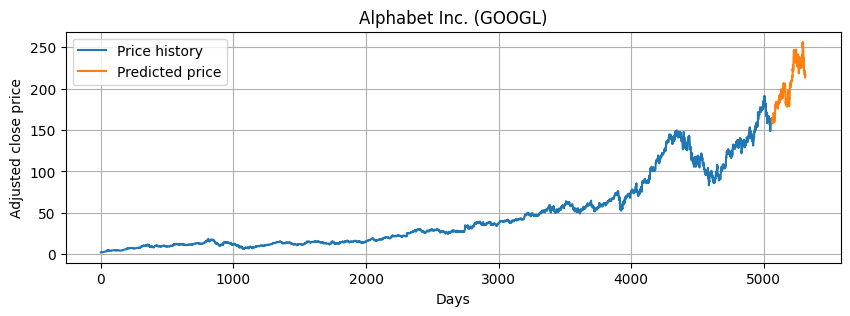

In [ ]:
T = 252

price_future = np.ones(T)*price[-1]

for t in range(T-1):
  ret = cagr/252 + np.random.randn()*v_annual/np.sqrt(252)
  price_future[t+1] = price_future[t] * (1+ret)

plt.figure(figsize=(10,3), dpi=100)
plt.plot(price, label='Price history')
plt.plot(np.arange(T)+len(price), price_future, label='Predicted price')
plt.grid(True)
plt.xlabel('Days')
plt.ylabel('Adjusted close price')
plt.title('Alphabet Inc. (GOOGL)')
plt.legend()
plt.show()

<br>

By running the above simulation for 10000 instances, we can display the histogram of the value that this asset will be evaluated after one year, as follows.



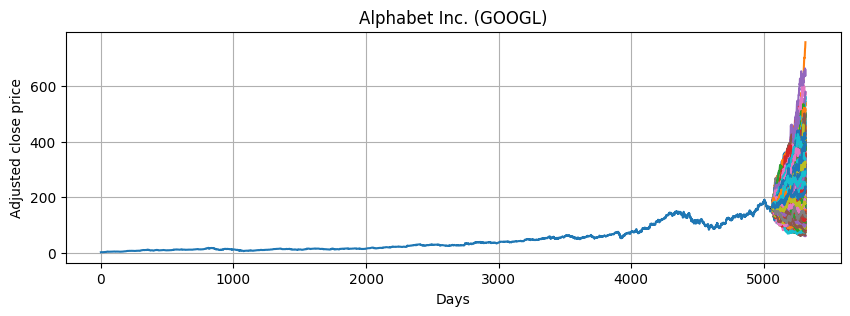

Expected value: 205.86602954464007
5-percentile value: 118.82368307020602
Prob_double: 0.0481


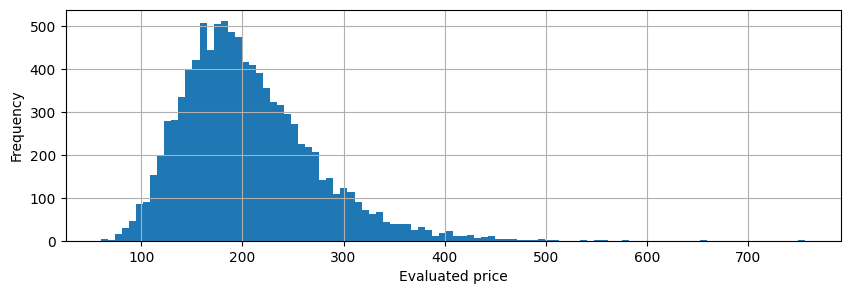

In [ ]:
N = 10000

price_final = np.zeros(N)

plt.figure(figsize=(10,3), dpi=100)
plt.plot(price)

for n in range(N):
  price_future = np.ones(T)*price[-1]

  for t in range(T-1):
    ret = cagr/252 + np.random.randn()*v_annual/np.sqrt(252)
    price_future[t+1] = price_future[t] * (1+ret)
  price_final[n] = price_future[-1]

  plt.plot(np.arange(T)+len(price), price_future)

plt.grid(True)
plt.xlabel('Days')
plt.ylabel('Adjusted close price')
plt.title('Alphabet Inc. (GOOGL)')
plt.show()

Expected_value = np.mean(price_final)
Five_percentile = np.percentile(price_final,5)
Prob_double = np.sum(price_final>price[-1]*2)/N
print (f'Expected value: {Expected_value}')
print (f'5-percentile value: {Five_percentile}')
print (f'Prob_double: {Prob_double}')

plt.figure(figsize=(10,3), dpi=100)
plt.hist(price_final, bins=100)
plt.grid(True)
plt.xlabel('Evaluated price')
plt.ylabel('Frequency')
plt.show()

<br>

<br>

What is the expected value that this asset will be evaluated, after one year? What is the minimum value that this asset will be evaluated with 95% probability, after one year? What is the probability that the value of this asset will be doubled in the next year?



Expected value: 205.86602954464007
5-percentile value: 118.82368307020602
Prob_double: 0.0481


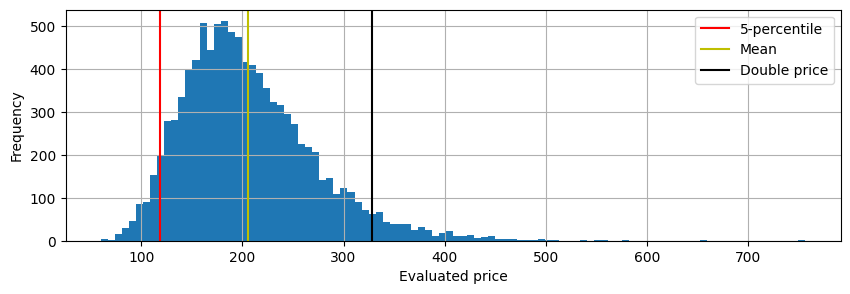

In [ ]:
Expected_value = np.mean(price_final)
Five_percentile = np.percentile(price_final,5)
Prob_double = np.sum(price_final>price[-1]*2)/N
print (f'Expected value: {Expected_value}')
print (f'5-percentile value: {Five_percentile}')
print (f'Prob_double: {Prob_double}')

plt.figure(figsize=(10,3), dpi=100)
plt.hist(price_final, bins=100)
plt.axvline(Five_percentile, color='r', label='5-percentile')
plt.axvline(Expected_value, color='y', label='Mean')
plt.axvline(price[-1]*2, color='k', label='Double price')
plt.grid(True)
plt.legend()
plt.xlabel('Evaluated price')
plt.ylabel('Frequency')
plt.show()

<br>

---
<br>

<div style="text-align: left">
References:
  
1) https://en.wikipedia.org/wiki/Monte_Carlo_method
  
2) https://towardsdatascience.com/monte-carlo-simulations-with-python-part-1-f5627b7d60b0

3) https://en.wikipedia.org/wiki/Volume_of_an_n-ball
</div>


